In [1]:
%cd NISP-Dataset/Hindi_master

/data/himanshu/NISP-Dataset/Hindi_master


/home/himanshu/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import pandas as pd
import numpy as np
import librosa
import torch

from datasets import Dataset
from transformers import (
    WhisperFeatureExtractor,
    WhisperForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
noisy_df = pd.read_csv("/data/himanshu/NISP-Dataset/noisy_dataset.csv")

In [4]:
df = noisy_df
df = df.rename(columns={
    "File_Path": "file_path",
    "Native_State": "label_text"
})

dataset = Dataset.from_pandas(df)

In [19]:
df.head()

,file_path,label_text
0,../Merged_Audio_Noisy/Hin_0092_Hin_f_0008.wav,Uttar_Pradesh
1,../Merged_Audio_Noisy/Hin_0077_Eng_f_7341.wav,Maharashtra
2,../Merged_Audio_Noisy/Hin_0093_Hin_f_0023.wav,Maharashtra
3,../Merged_Audio_Noisy/Hin_0020_Eng_m_5447.wav,Uttar_Pradesh
4,../Merged_Audio_Noisy/Hin_0013_Eng_m_5222.wav,Bihar


In [20]:
df.shape

(7839, 2)

In [21]:
df.describe

<bound method NDFrame.describe of                                           file_path     label_text
0     ../Merged_Audio_Noisy/Hin_0092_Hin_f_0008.wav  Uttar_Pradesh
1     ../Merged_Audio_Noisy/Hin_0077_Eng_f_7341.wav    Maharashtra
2     ../Merged_Audio_Noisy/Hin_0093_Hin_f_0023.wav    Maharashtra
3     ../Merged_Audio_Noisy/Hin_0020_Eng_m_5447.wav  Uttar_Pradesh
4     ../Merged_Audio_Noisy/Hin_0013_Eng_m_5222.wav          Bihar
...                                             ...            ...
7834  ../Merged_Audio_Noisy/Hin_0058_Hin_m_0005.wav          Delhi
7835  ../Merged_Audio_Noisy/Hin_0060_Eng_m_0001.wav          Bihar
7836  ../Merged_Audio_Noisy/Hin_0053_Eng_f_6538.wav        Gujarat
7837  ../Merged_Audio_Noisy/Hin_0014_Eng_m_0004.wav          Bihar
7838  ../Merged_Audio_Noisy/Hin_0040_Hin_m_0002.wav      Rajasthan

[7839 rows x 2 columns]>

In [5]:
labels = sorted(df["label_text"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

def encode_labels(batch):
    batch["label"] = label2id[batch["label_text"]]
    return batch

dataset = dataset.map(encode_labels)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

In [6]:
def load_audio(batch):
    audio, _ = librosa.load(batch["file_path"], sr=16000)

    # OPTIONAL (safe): ensure fixed length (3 sec)
    max_len = 16000 * 10
    if len(audio) > max_len:
        audio = audio[:max_len]
    else:
        audio = np.pad(audio, (0, max_len - len(audio)))

    batch["audio"] = audio
    return batch

dataset = dataset.map(load_audio)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

/usr/lib/python3/dist-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/usr/lib/python3/dist-packages/paramiko/transport.py:261: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


In [7]:
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

In [8]:
model_name = "openai/whisper-small"

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)

model = WhisperForAudioClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)

/home/himanshu/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def preprocess(batch):
    inputs = feature_extractor(
        batch["audio"],
        sampling_rate=16000,
        return_tensors="pt"
    )
    batch["input_features"] = inputs.input_features[0]
    return batch

train_dataset = train_dataset.map(preprocess, remove_columns=["audio", "file_path", "label_text"])
val_dataset = val_dataset.map(preprocess, remove_columns=["audio", "file_path", "label_text"])

Map:   0%|          | 0/6271 [00:00<?, ? examples/s]

Map:   0%|          | 0/1568 [00:00<?, ? examples/s]

In [10]:
from dataclasses import dataclass
from typing import List, Dict

@dataclass
class DataCollator:
    def __call__(self, features: List[Dict]):
        input_features = [f["input_features"] for f in features]
        labels = [f["label"] for f in features]

        batch = {
            "input_features": torch.tensor(input_features),
            "labels": torch.tensor(labels)
        }
        return batch

data_collator = DataCollator()

In [11]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    accuracy = accuracy_score(labels, preds)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [12]:
training_args = TrainingArguments(
    output_dir="./whisper-dialect",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    num_train_epochs=10,
    learning_rate=1e-5,   # lower than wav2vec
    warmup_steps=500,
    fp16=True,
    save_total_limit=2
)

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/home/himanshu/.local/lib/python3.10/site-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [14]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.475900,0.511773,0.853316,0.849436,0.864834,0.853316
2,0.130900,0.280508,0.938776,0.940120,0.948290,0.938776
3,0.004900,0.152442,0.974490,0.974478,0.975038,0.974490
4,0.073600,0.188100,0.965561,0.965537,0.966708,0.965561
5,0.041800,0.256508,0.964286,0.964357,0.966688,0.964286
6,0.000100,0.094187,0.983418,0.983418,0.983586,0.983418
7,0.069000,0.139623,0.975765,0.975813,0.976390,0.975765
8,0.000000,0.103390,0.985332,0.985387,0.985751,0.985332
9,0.000000,0.098104,0.985332,0.985405,0.985859,0.985332
10,0.000000,0.094443,0.984694,0.984768,0.985203,0.984694


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfi

TrainOutput(global_step=15680, training_loss=0.19588116773714004, metrics={'train_runtime': 14421.5242, 'train_samples_per_second': 4.348, 'train_steps_per_second': 1.087, 'total_flos': 7.874717756961598e+18, 'train_loss': 0.19588116773714004, 'epoch': 10.0})

In [15]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.09444329142570496, 'eval_accuracy': 0.9846938775510204, 'eval_f1': 0.9847677343863849, 'eval_precision': 0.9852030102791725, 'eval_recall': 0.9846938775510204, 'eval_runtime': 253.8082, 'eval_samples_per_second': 6.178, 'eval_steps_per_second': 1.544, 'epoch': 10.0}


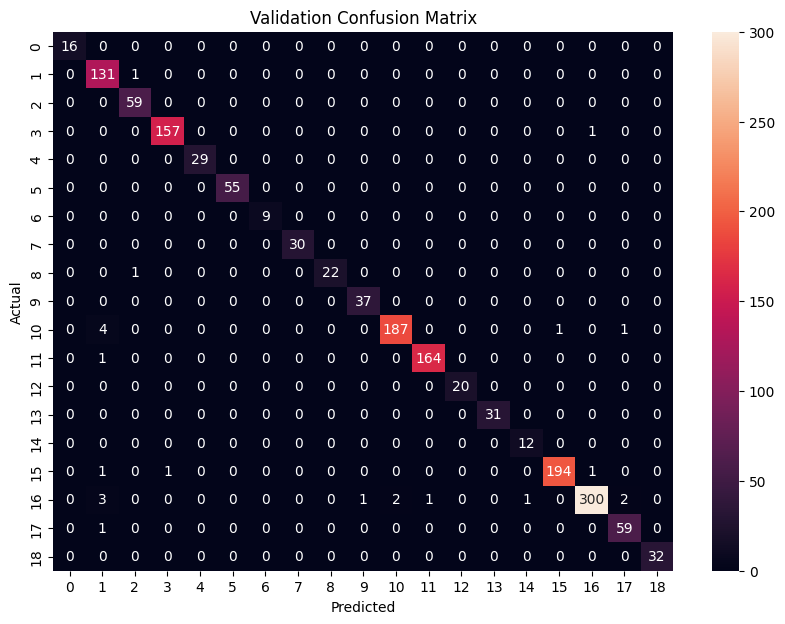

In [18]:
val_outputs = trainer.predict(val_dataset)

val_logits = val_outputs.predictions
val_labels = val_outputs.label_ids
val_preds = np.argmax(val_logits, axis=-1)

cm_val = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_val, annot=True, fmt='d')
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()